In [ ]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import csv
from pathlib import Path
from functools import partial

import torch
import matplotlib.pyplot as plt

from scripts.common import load_model, load_dataset
from scripts.perceptual_sim import load_dino, get_image_features, compute_patchwise_similarity

device = torch.device('cuda')  if  torch.cuda.is_available() else torch.device('cpu')

In [ ]:
model_name = 'vae'
model_checkpoint = Path("data/results/figure1/combgen_shapes3d_shape_hue_vae_on:2025-11-19_14-21/epoch=144-step=97875.ckpt")
vae, device = load_model(model_name, model_checkpoint, compile=False)

model_name = 'wae'
model_checkpoint = Path("data/results/figure1/combgen_shapes3d_shape_hue_wae_on:2025-11-19_16-58/epoch=147-step=99900.ckpt")
wae, device = load_model(model_name, model_checkpoint, compile=False)

model_name = 'sa'
model_checkpoint = Path("data/results/figure1/combgen_shapes3d_shape_hue_sa_on:2025-11-19_18-02/epoch=147-step=99900.ckpt")
sa, device = load_model(model_name, model_checkpoint, compile=False)

In [ ]:
# model_id = 'facebook/dinov2-small-imagenet1k-1-layer'
# model_id = 'facebook/dinov2-base-patch16-224'
# model_id = 'facebook/dinov2-small'
# model_id = 'facebook/dinov2-base'
model_id = 'facebook/dinov3-vit7b16-pretrain-lvd1689m'
dino, processor = load_dino(model_id, device)
get_features = partial(get_image_features, model=dino, processor=processor, device=device)

In [ ]:
filter_expr = "( shape == 3 ) & ( object_hue > 0.5 )"

train_dataset, test_dataset, train_loader, test_loader = load_dataset('shapes3d', filter_expr, batch_size=1)

In [ ]:
def center_mask(img, radius=24):
    h, w = img.shape[:2]
    y, x = np.ogrid[:h, :w]
    cx, cy = w//2, h//2
    mask = (x-cx)**2 + (y-cy)**2 <= radius**2

    out = img.copy()
    out[~mask] = 0
    return out, mask

In [ ]:
import cv2
import numpy as np

def segment_shapes3d_edges(img):
    img = (img * 255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # detect edges
    edges = cv2.Canny(gray, 40, 120)

    # close gaps in the contour
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # find contours
    contours, _ = cv2.findContours(
        closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # choose contour closest to center
    h, w = gray.shape
    cx, cy = w//2, h//2

    best = None
    best_dist = float("inf")

    for c in contours:
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue

        x = int(M["m10"]/M["m00"])
        y = int(M["m01"]/M["m00"])

        dist = (x-cx)**2 + (y-cy)**2
        if dist < best_dist:
            best = c
            best_dist = dist

    mask = np.zeros(gray.shape, np.uint8)
    cv2.drawContours(mask, [best], -1, 255, -1)

    masked = img.copy()
    masked[mask == 0] = 0

    return masked, mask

In [ ]:
def canny_color(img):

    img = img.astype(np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    # img = cv2.bilateralFilter(img, 7, 50, 50)

    # Sobel gradients for each channel
    gx = []
    gy = []

    for c in range(3):
        gx.append(cv2.Sobel(img[:,:,c], cv2.CV_32F, 1, 0, ksize=3))
        gy.append(cv2.Sobel(img[:,:,c], cv2.CV_32F, 0, 1, ksize=3))

    gx = np.stack(gx)
    gy = np.stack(gy)

    # combined gradient magnitude across channels
    grad = np.sqrt((gx**2 + gy**2).sum(axis=0))

    # normalize to 0–255
    grad = cv2.normalize(grad, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    edges = cv2.Canny(grad, 40, 120)

    return edges

def segment_object(img):

    edges = canny_color(img)

    # close gaps
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours,_ = cv2.findContours(
        closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    h,w = img.shape[:2]
    cx,cy = w//2, h//2

    best=None
    best_dist=float("inf")

    for c in contours:

        M = cv2.moments(c)
        if M["m00"] == 0:
            continue

        x = int(M["m10"]/M["m00"])
        y = int(M["m01"]/M["m00"])

        dist = (x-cx)**2 + (y-cy)**2

        if dist < best_dist:
            best=c
            best_dist=dist

    mask = np.zeros((h,w), np.uint8)
    cv2.drawContours(mask,[best],-1,255,-1)

    masked = img.copy()
    masked[mask==0] = 0

    return masked, mask

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


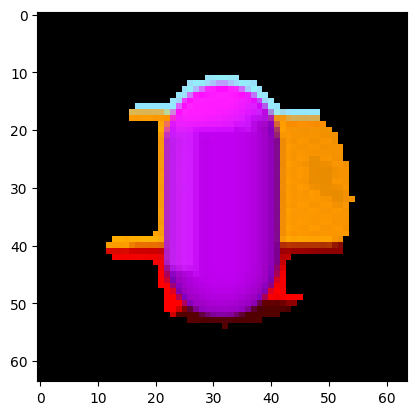

In [273]:
# out, mask = center_mask(img.squeeze(0).cpu().numpy().transpose(1, 2, 0))
out, mask = segment_object(img.squeeze(0).cpu().numpy().transpose(1, 2, 0))
out, mask = center_mask(out, radius=22)
print(mask)
plt.imshow(out)

In [ ]:
torch_mask = torch.from_numpy(mask[None, None]).to(device=device)

gt_features = get_features(img * torch_mask)
vae_r = vae.reconstruction(img).clip(0,1)
wae_r = wae.reconstruction(img).clip(0,1)
sa_r = sa.reconstruction(img).clip(0, 1)

vae_features = get_features(vae_r * torch_mask)
wae_features = get_features(wae_r * torch_mask)
sa_features = get_features(sa_r * torch_mask)


def compute_patchwise_similarity(emb1, emb2):
    B, Np, _ = emb1.shape
    cutoff_idx = int(np.ceil(Np * 0.33))
    emb1 = emb1.flatten(0, 1)
    emb2 = emb2.flatten(0, 1)
    similarities = torch.vmap(torch.dot)(emb1, emb2)  # Embeddings are already normalized
    similarities = similarities.unflatten(0, (B, Np))
    
    sorted_similarities = torch.sort(similarities, dim=1)[0]
    return similarities, sorted_similarities[:, :cutoff_idx].mean(dim=1)


vae_patch_sim, vae_sim = compute_patchwise_similarity(gt_features, vae_features)
wae_patch_sim, wae_sim = compute_patchwise_similarity(gt_features, wae_features)
sa_patch_sim, sa_sim = compute_patchwise_similarity(gt_features, sa_features)

In [270]:
vae_sim, wae_sim, sa_sim

(tensor([0.6572], device='cuda:0'),
 tensor([0.5293], device='cuda:0'),
 tensor([0.6757], device='cuda:0'))

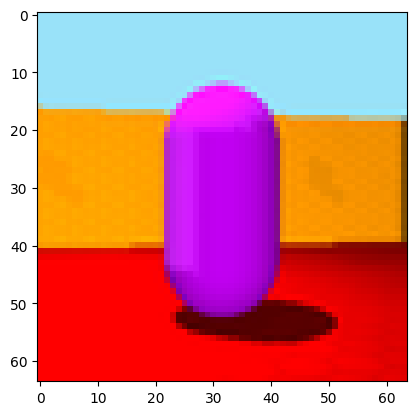

In [271]:
# img = train_dataset[200000][0].to(device)[None]
img = test_dataset[800][0].to(device)[None]
plt.imshow(img.squeeze(0).cpu().numpy().transpose(1, 2, 0))

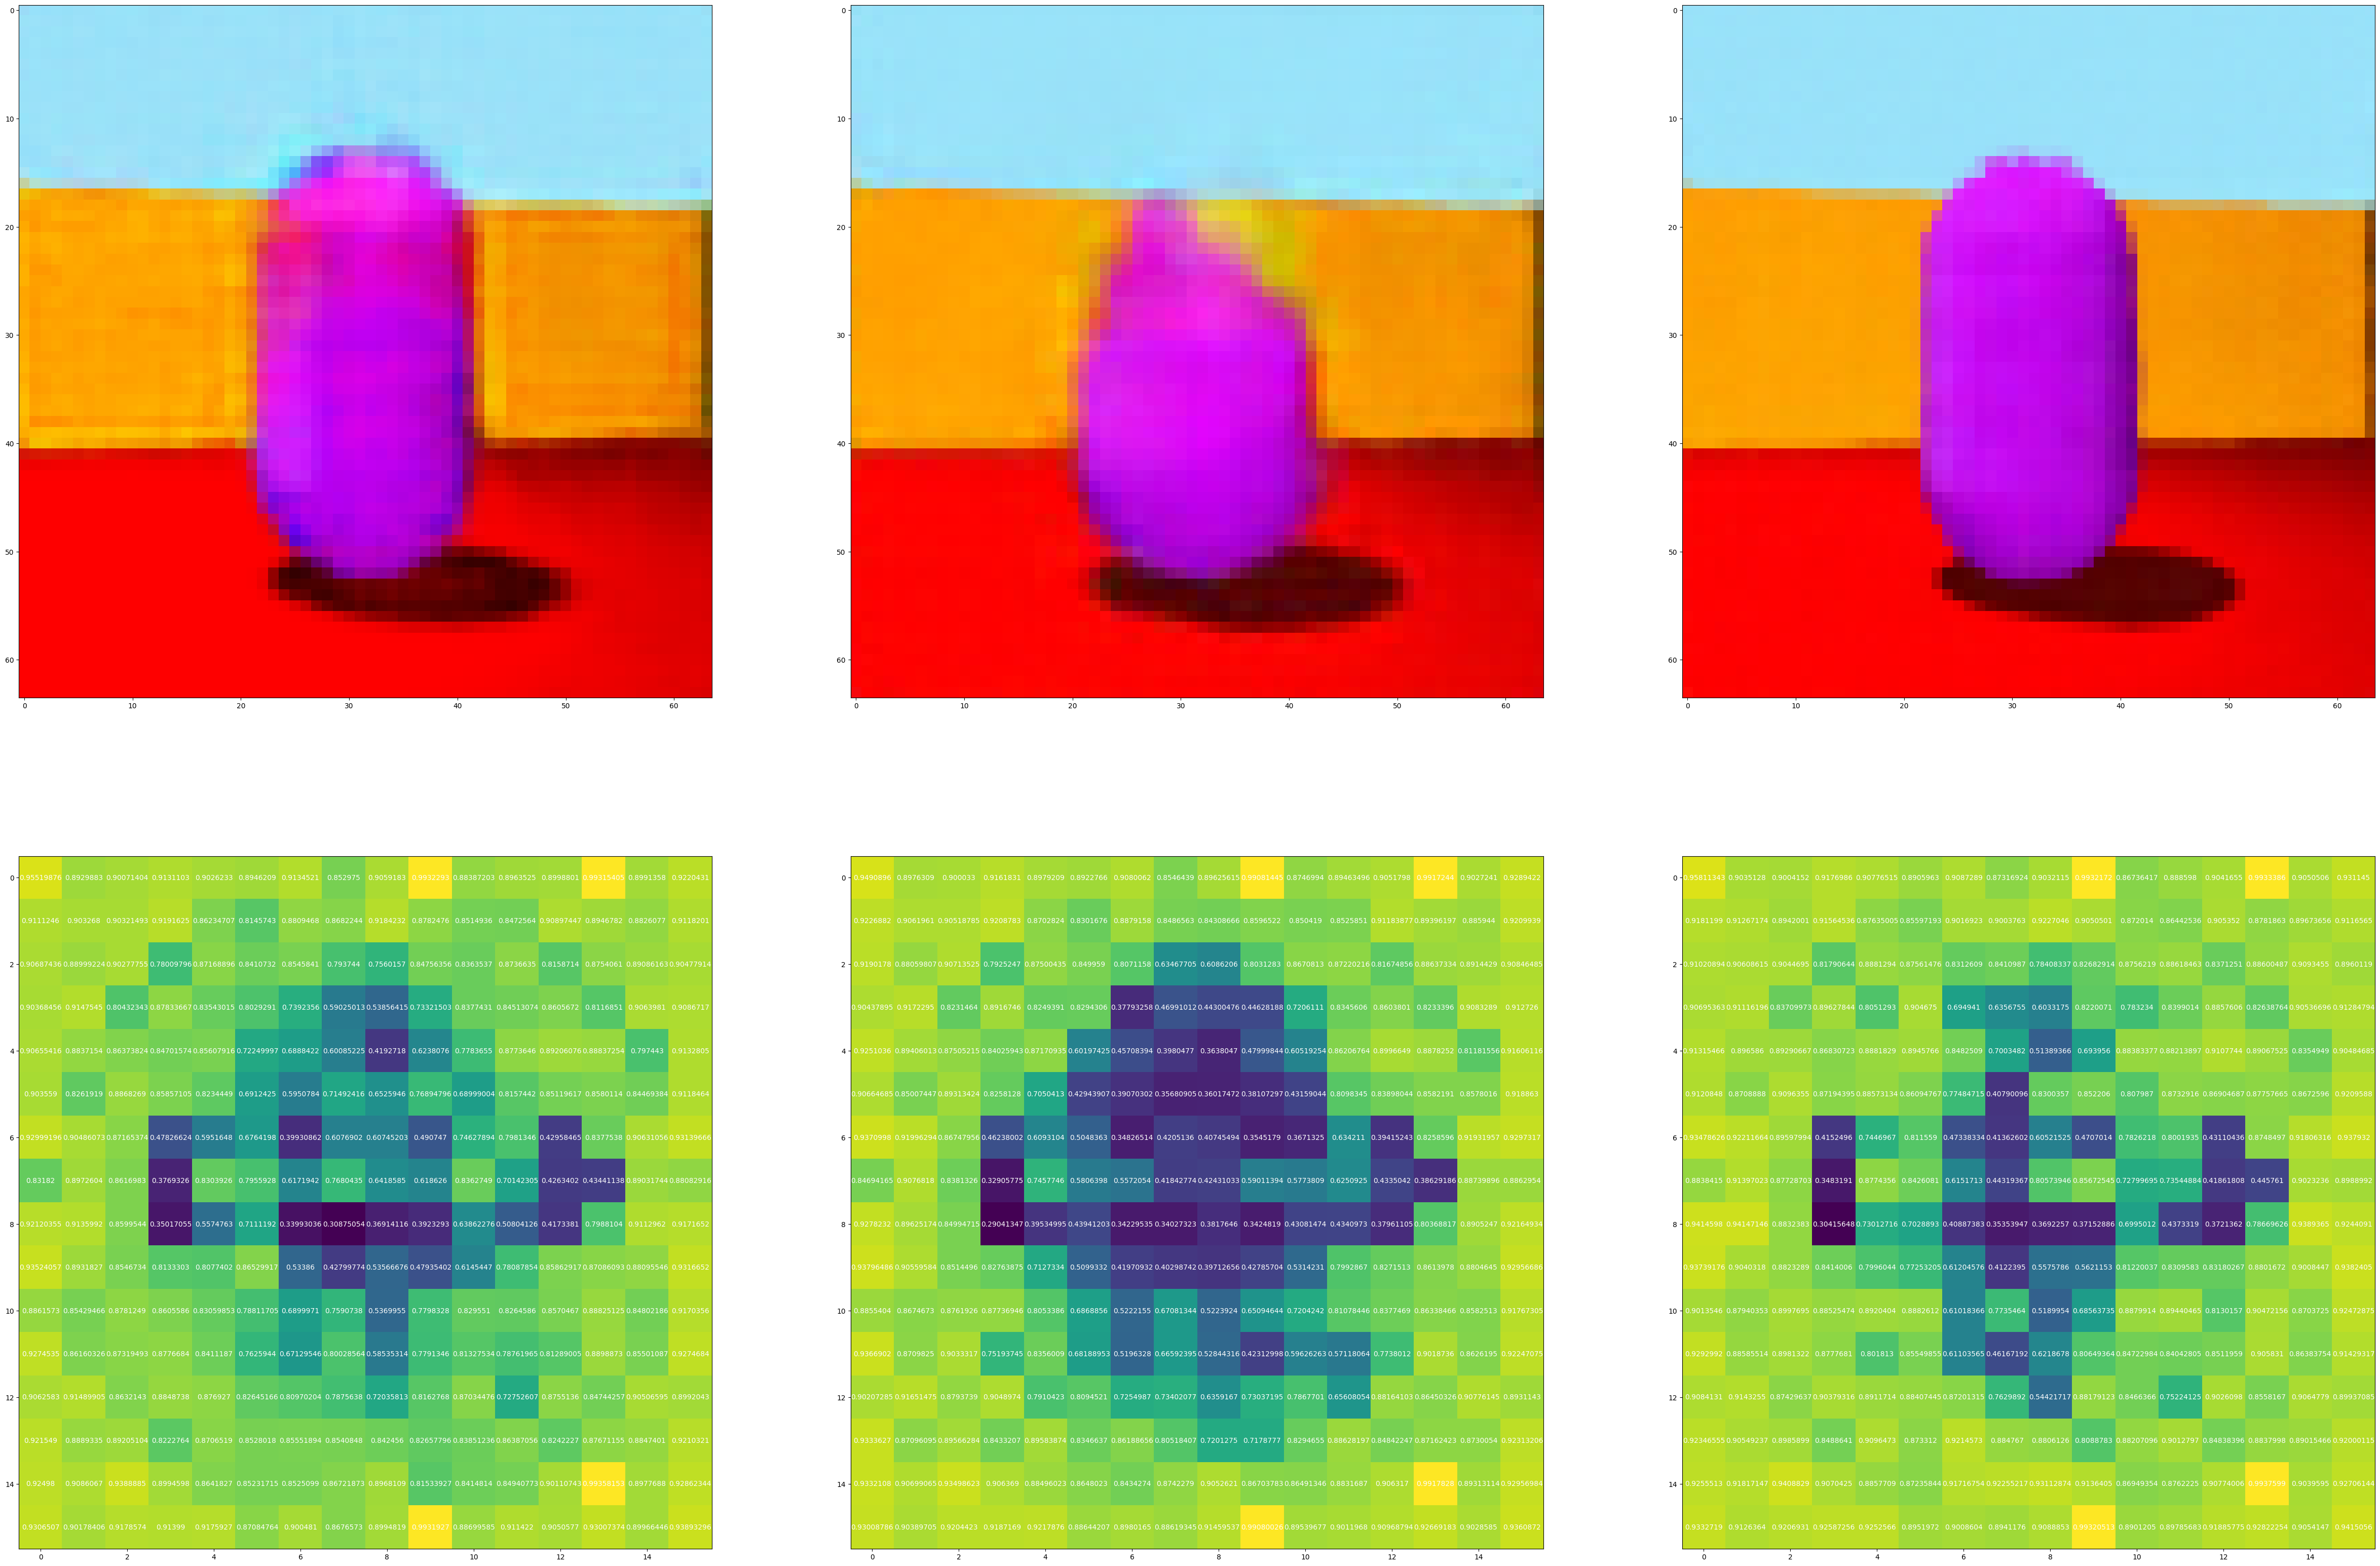

In [272]:
def plot_sim_heatmap(sim, ax):
    sim = sim.cpu().numpy().reshape(16, 16)
    im = ax.imshow(sim)
    # Loop over data dimensions and create text annotations.
    for i in range(sim.shape[0]):
        for j in range(sim.shape[1]):
            text = ax.text(j, i, sim[i, j], ha="center", va="center", color="w")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(60, 40))

axes[0, 0].imshow(vae_r[0].cpu().numpy().transpose(1, 2, 0), vmin=0,vmax=1)
axes[0, 1].imshow(wae_r[0].cpu().numpy().transpose(1, 2, 0), vmin=0,vmax=1)
axes[0, 2].imshow(sa_r[0].cpu().numpy().transpose(1, 2, 0), vmin=0, vmax=1)

plot_sim_heatmap(vae_patch_sim[0, 1:], axes[1, 0])
plot_sim_heatmap(wae_patch_sim[0, 1:], axes[1, 1])
plot_sim_heatmap(sa_patch_sim[0, 1:], axes[1, 2])